In [1]:
import pandas as pd
import tensorflow as tf
import numpy as np
import gc
import time
#import matplotlib.pyplot as plt
#from livelossplot.keras import PlotLossesCallback
from tensorflow.keras.callbacks import ReduceLROnPlateau
#from keras.models import load_model
import csv
from itertools import chain
from matplotlib import pyplot as plt

D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
D:\ProgramData\Anaconda3\envs\tensorflow210\lib\s

### 设置GPU显存按需分配

In [2]:
#如果没有装GPU版本，这部分就不用写，但是如果不用GPU加速计算，使用CPU将会严重限制模型的训练速度
gpus = tf.config.experimental.list_physical_devices('GPU') 
if gpus:
  try:

    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:

    print(e)

1 Physical GPUs, 1 Logical GPUs


### 载入数据

In [4]:
data_train=pd.read_csv('F:/TensorFlow/traindata20240408only_evi.csv',header=0,encoding='utf_8')
data_train.info()
data_train.num.unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1099 entries, 0 to 1098
Data columns (total 40 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   index      1099 non-null   int64  
 1   编号         1099 non-null   object 
 2   采样时        1099 non-null   object 
 3   海拔（m       1099 non-null   float64
 4   植被类        1099 non-null   object 
 5   细分类        649 non-null    object 
 6   建群种_       1099 non-null   object 
 7   耕作方        983 non-null    object 
 8   备注         125 non-null    object 
 9   Field11    571 non-null    object 
 10  Field18    0 non-null      float64
 11  一级类        1099 non-null   object 
 12  二级类        1097 non-null   object 
 13  玉米小        1099 non-null   object 
 14  num        1099 non-null   int64  
 15  EVI230101  1099 non-null   int64  
 16  EVI230117  1099 non-null   int64  
 17  EVI230202  1099 non-null   int64  
 18  EVI230218  1099 non-null   int64  
 19  EVI230306  1099 non-null   int64  
 20  EVI23032

array([2, 1, 0], dtype=int64)

In [5]:
pd.set_option('display.max_rows', None)
print(data_train['num'].value_counts())

1    581
2    408
0    110
Name: num, dtype: int64


In [6]:
data_train.head()

,index,编号,采样时,海拔（m,植被类,细分类,建群种_,耕作方,备注,Field11,...,EVI230829,EVI230914,EVI230930,EVI231016,EVI231101,EVI231117,EVI231203,EVI231219,经度CGCS,纬度CGCS
0,0,0717－001,717,371.0,耕地,水浇地,玉米,一年两季,小麦,玉米,...,5857,5610,3042,1145,2028,1791,1959,1502,110.741866,35.569516
1,1,0717－002,717,371.0,耕地,水浇地,玉米,一年两季,小麦,玉米,...,5646,5624,2485,1202,2509,1962,2050,2500,110.749011,35.576882
2,2,0717－003,717,371.0,耕地,水浇地,玉米,一年两季,小麦,玉米,...,6288,5530,4588,3071,1423,1811,1528,1573,110.767722,35.562011
3,3,0717－004,717,371.0,耕地,水浇地,玉米,一年两季,小麦,玉米,...,4454,3792,2969,1685,1701,1742,1192,1882,110.785618,35.564559
4,4,0717－005,717,372.0,耕地,水浇地,玉米,一年两季,小麦,玉米,...,3977,3955,3351,1931,1995,2385,1895,2038,110.795413,35.567623


In [7]:
# 生成该区间的随意唯一索引
index = np.random.permutation(len(data_train))
# 用生成的乱的索引就能将其打乱了
data_all = data_train.iloc[index ,:]

### 切分数据

In [7]:
split_index = int(len(data_all)*0.7)
data_train = data_all.iloc[:split_index]

data_test = data_all.iloc[split_index:]
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2040 entries, 6599 to 3569
Columns: 243 entries, 编号 to 纬度CGCS
dtypes: float64(7), int64(234), object(2)
memory usage: 3.8+ MB


In [8]:
train_x = data_train.iloc[:,3:]
train_y = data_train.loc[:, ['num']] 

test_x = data_test.iloc[:,3:]
test_y = data_test.loc[:, ['num']] 
train_x.head(), train_y.head()

(      AET2201  AET2202  AET2203  AET2204  AET2205  AET2206  AET2207  AET2208  \
 3326        0        0       58      112      185      139      446      677   
 1668        0        0      380      382      407      355     1254      692   
 1238       75      176      334      233      150     1117     1402     1180   
 5936        0        0       21       67       23      259      213      264   
 949       124       67      148      171      157      175     1432      650   
 
       AET2209  AET2210  ...  SR220930b07  SR221024b01  SR221024b02  \
 3326      103      173  ...         1457         1427         2373   
 1668      354      548  ...          921          551         1377   
 1238      465      798  ...         1101         1037         2149   
 5936       49       13  ...         2827         2076         3139   
 949       253      589  ...         2538         2103         2583   
 
       SR221024b03  SR221024b04  SR221024b05  SR221024b06  SR221024b07  \
 3326     

### 类别数量

In [8]:
num_classes = data_train['num'].nunique()
print(num_classes)

3


### 不测试时使用全部数据训练

In [9]:
train_x = data_train.iloc[:,15:]
train_y = data_train.loc[:, ['num']] 

In [10]:
train_x.head()

,EVI230101,EVI230117,EVI230202,EVI230218,EVI230306,EVI230322,EVI230407,EVI230423,EVI230509,EVI230525,...,EVI230829,EVI230914,EVI230930,EVI231016,EVI231101,EVI231117,EVI231203,EVI231219,经度CGCS,纬度CGCS
0,1865,1531,1144,1640,2547,4964,5128,6751,5292,2753,...,5857,5610,3042,1145,2028,1791,1959,1502,110.741866,35.569516
1,1601,1917,1174,2111,2688,4662,4956,6654,4899,2162,...,5646,5624,2485,1202,2509,1962,2050,2500,110.749011,35.576882
2,1872,1733,743,1709,2633,4637,4882,5516,5618,2565,...,6288,5530,4588,3071,1423,1811,1528,1573,110.767722,35.562011
3,1834,1617,809,2162,1368,2905,4610,5736,4097,3389,...,4454,3792,2969,1685,1701,1742,1192,1882,110.785618,35.564559
4,1661,2068,901,2325,2415,4326,3518,5926,5175,3629,...,3977,3955,3351,1931,1995,2385,1895,2038,110.795413,35.567623


### 顺序编码转独热编码

In [11]:
train_y = tf.keras.utils.to_categorical(train_y)

In [12]:
train_x.head()
train_y

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       ...,
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]], dtype=float32)

### 定义损失函数为Focal Loss

In [13]:
def multi_category_focal_loss2(gamma=2., alpha=.25):
    """
    focal loss for multi category of multi label problem
    适用于多分类或多标签问题的focal loss
    alpha控制真值y_true为1/0时的权重
        1的权重为alpha, 0的权重为1-alpha
    当你的模型欠拟合，学习存在困难时，可以尝试适用本函数作为loss
    当模型过于激进(无论何时总是倾向于预测出1),尝试将alpha调小
    当模型过于惰性(无论何时总是倾向于预测出0,或是某一个固定的常数,说明没有学到有效特征)
        尝试将alpha调大,鼓励模型进行预测出1。
    Usage:
     model.compile(loss=[multi_category_focal_loss2(alpha=0.25, gamma=2)], metrics=["accuracy"], optimizer='adam')
    """
    epsilon = 1.e-7
    gamma = float(gamma)
    alpha = tf.constant(alpha, dtype=tf.float32)

    def multi_category_focal_loss2_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
    
        alpha_t = y_true*alpha + (tf.ones_like(y_true)-y_true)*(1-alpha)
        y_t = tf.multiply(y_true, y_pred) + tf.multiply(1-y_true, 1-y_pred)
        y_t = tf.clip_by_value(y_t, epsilon, 1. - epsilon)#这句是后加的
        ce = -tf.math.log(y_t)
        weight = tf.math.pow(tf.subtract(1., y_t), gamma)
        fl = tf.multiply(tf.multiply(weight, ce), alpha_t)
        loss = tf.reduce_mean(fl)
        return loss
    return multi_category_focal_loss2_fixed

### 模型构建

In [16]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(1024,input_dim=25))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(512,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(256,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(128,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(64,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(32,activation='relu'))#注：如果后面再加16，8，16，32这样的全连结层，精度反而会变低
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(16,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(8,activation='relu'))
model.add(tf.keras.layers.Dropout(rate=0.5))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))#不懂为啥有时候对不上非要+1
# 让学习率自动变化
reduce_lr = ReduceLROnPlateau(monitor='loss',factor=0.1, patience=20, mode='auto')
model.compile(loss=multi_category_focal_loss2(2), metrics=['acc'], optimizer='adam')#adam优化
#顺序编码用loss='sparse_categorical_crossentropy'
#独热编码用loss='categorical_crossentropy'
tf.random.set_random_seed(1024)
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_9 (Dense)              (None, 1024)              26624     
_________________________________________________________________
batch_normalization_7 (Batch (None, 1024)              4096      
_________________________________________________________________
dense_10 (Dense)             (None, 512)               524800    
_________________________________________________________________
batch_normalization_8 (Batch (None, 512)               2048      
_________________________________________________________________
dense_11 (Dense)             (None, 256)               131328    
_________________________________________________________________
batch_normalization_9 (Batch (None, 256)               1024      
_________________________________________________________________
dense_12 (Dense)             (None, 128)              

### 开始训练

In [17]:
e = 200
start = time.perf_counter()#time.process_time()测的时间偏长
history = model.fit(train_x,train_y, epochs=e,batch_size=32,verbose=1,callbacks=[reduce_lr])#callbacks=[reduce_lr],batch_size=16,validation_data=(validation_x,validation_y)
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Epoch 1/200
1099/1099 [==============================] - 2s 2ms/sample - loss: 0.0739 - acc: 0.6415
Epoch 2/200
1099/1099 [==============================] - 0s 252us/sample - loss: 0.0395 - acc: 0.7334
Epoch 3/200
1099/1099 [==============================] - 0s 266us/sample - loss: 0.0361 - acc: 0.7680
Epoch 4/200
1099/1099 [==============================] - 0s 269us/sample - loss: 0.0352 - acc: 0.7780
Epoch 5/200
1099/1099 [==============================] - 0s 258us/sample - loss: 0.0340 - acc: 0.7880
Epoch 6/200
1099/1099 [==============================] - 0s 251us/sample - loss: 0.0338 - acc: 0.7753
Epoch 7/200
1099/1099 [==============================] - 0s 257us/sample - loss: 0.0309 - acc: 0.7889
Epoch 8/200
1099/1099 [==============================] - 0s 254us/sample - loss: 0.0310 - acc: 0.7962
Epoch 9/200
1099/1099 [==============================] - 0s 252us/sample - loss: 0.0313 - ac

1099/1099 [==============================] - 0s 262us/sample - loss: 0.0220 - acc: 0.8444
Epoch 78/200
1099/1099 [==============================] - 0s 270us/sample - loss: 0.0346 - acc: 0.7989
Epoch 79/200
1099/1099 [==============================] - 0s 254us/sample - loss: 0.0252 - acc: 0.8180
Epoch 80/200
1099/1099 [==============================] - 0s 255us/sample - loss: 0.0232 - acc: 0.8417
Epoch 81/200
1099/1099 [==============================] - 0s 254us/sample - loss: 0.0257 - acc: 0.8253
Epoch 82/200
1099/1099 [==============================] - 0s 273us/sample - loss: 0.0256 - acc: 0.8135
Epoch 83/200
1099/1099 [==============================] - 0s 251us/sample - loss: 0.0226 - acc: 0.8335
Epoch 84/200
1099/1099 [==============================] - 0s 253us/sample - loss: 0.0207 - acc: 0.8480
Epoch 85/200
1099/1099 [==============================] - 0s 259us/sample - loss: 0.0222 - acc: 0.8389
Epoch 86/200
1099/1099 [==============================] - 0s 283us/sample - loss: 0.02

1099/1099 [==============================] - 0s 245us/sample - loss: 0.0176 - acc: 0.8517
Epoch 157/200
1099/1099 [==============================] - 0s 252us/sample - loss: 0.0161 - acc: 0.8517
Epoch 158/200
1099/1099 [==============================] - 0s 247us/sample - loss: 0.0160 - acc: 0.8499
Epoch 159/200
1099/1099 [==============================] - 0s 245us/sample - loss: 0.0151 - acc: 0.8590
Epoch 160/200
1099/1099 [==============================] - 0s 245us/sample - loss: 0.0176 - acc: 0.8535
Epoch 161/200
1099/1099 [==============================] - 0s 257us/sample - loss: 0.0178 - acc: 0.8535
Epoch 162/200
1099/1099 [==============================] - 0s 262us/sample - loss: 0.0145 - acc: 0.8608
Epoch 163/200
1099/1099 [==============================] - 0s 286us/sample - loss: 0.0146 - acc: 0.8644
Epoch 164/200
1099/1099 [==============================] - 0s 241us/sample - loss: 0.0154 - acc: 0.8553
Epoch 165/200
1099/1099 [==============================] - 0s 252us/sample - l

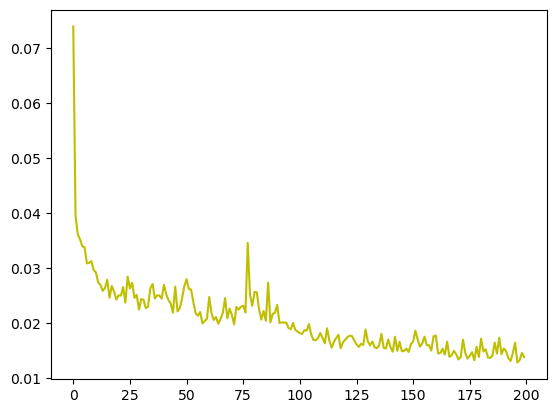

In [18]:
plt.plot(range(200),history.history.get('loss'),color =  'y')

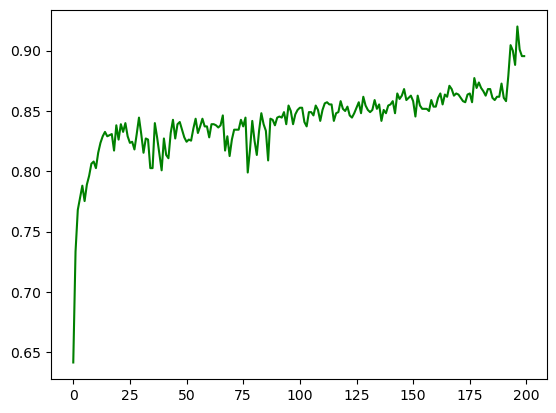

In [19]:
plt.plot(range(200),history.history.get('acc'),color =  'g')

In [20]:
model.save(r'F:/TensorFlow/model_data/model_YR_20240828.h5')

### 计算准确率

In [15]:
test_r = pd.DataFrame(model.predict_classes(test_x,verbose=1))
test_r = test_r.values
acc_array = (test_y == test_r)
print('准确率：', np.sum(acc_array!=0)/len(acc_array))

2040/2040 [==============================] - 0s 141us/sample
准确率： num    0.795098
dtype: float64


In [23]:
test_r
print(np.array(test_r).tostring())

b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x

D:\ProgramData\Anaconda3\envs\tensorflow210\lib\site-packages\ipykernel_launcher.py:2: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  


### 各类别准确率

In [34]:
test_y = list(chain.from_iterable(test_y))
test_r = list(chain.from_iterable(test_r))

def count_nums(true_labels, num_classes):
    initial_value = 0
    list_length = num_classes
    list_data = [ initial_value for i in range(list_length)]
    for i in range(0, num_classes):
        list_data[i] = true_labels.count(i)
    return list_data

def accuracy(confusion_matrix, true_labels, num_classes):
    # 各个类别的测试样本的个数
    list_data = count_nums(true_labels, num_classes)
 
    # 各个类别正确分类的个数
    initial_value = 0
    list_length = num_classes
    true_pred = [ initial_value for i in range(list_length)]
    for i in range(0,num_classes):
        true_pred[i] = confusion_matrix[i][i]
 
    # 计算各个样本被正确分类的正确率
    classveg = []
    acc = []
    for i in range(0, num_classes):
        classveg.append(0)
        acc.append(0)
 
    for i in range(0,num_classes):
        classveg[i] = i
        acc[i] = float(true_pred[i] / list_data[i])
    
    z = pd.DataFrame(list(zip(classveg,acc,list_data)), columns=['class_code', 'acc','count'])
    return z

op = tf.math.confusion_matrix(test_y, test_r)

acc = accuracy(op, test_y, num_classes)
print(acc)

ValueError: Dimension 0 in both shapes must be equal, but are 3 and 2148. Shapes are [3] and [2148].
	From merging shape 0 with other shapes. for 'confusion_matrix/stack_1' (op: 'Pack') with input shapes: [3], [2148].

### 出结果

In [21]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/testresult20240828_2023.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('E:/evi+xy.csv',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 4s 37us/sample
1
100000/100000 [==============================] - 3s 34us/sample
2
100000/100000 [==============================] - 3s 35us/sample
3
100000/100000 [==============================] - 3s 34us/sample
4
100000/100000 [==============================] - 3s 34us/sample
5
100000/100000 [==============================] - 3s 34us/sample
6
100000/100000 [==============================] - 4s 35us/sample
7
100000/100000 [==============================] - 4s 35us/sample
8
100000/100000 [==============================] - 4s 35us/sample
9
100000/100000 [==============================] - 3s 34us/sample
10
100000/100000 [==============================] - 3s 34us/sample
11
100000/100000 [==============================] - 3s 35us/sample
12
100000/100000 [==============================] - 3s 35us/sample
13
100000/100000 [==============================] - 3s 34us/sample
14
100000/100000 [==============================] - 3s 34us/sample
15
10

100000/100000 [==============================] - 3s 34us/sample
123
100000/100000 [==============================] - 3s 34us/sample
124
100000/100000 [==============================] - 3s 34us/sample
125
100000/100000 [==============================] - 3s 34us/sample
126
100000/100000 [==============================] - 3s 34us/sample
127
100000/100000 [==============================] - 3s 34us/sample
128
100000/100000 [==============================] - 3s 34us/sample
129
100000/100000 [==============================] - 3s 34us/sample
130
100000/100000 [==============================] - 3s 34us/sample
131
100000/100000 [==============================] - 3s 34us/sample
132
100000/100000 [==============================] - 4s 35us/sample
133
100000/100000 [==============================] - 4s 35us/sample
134
100000/100000 [==============================] - 3s 34us/sample
135
100000/100000 [==============================] - 3s 33us/sample
136
100000/100000 [==============================] -

100000/100000 [==============================] - 3s 34us/sample
243
100000/100000 [==============================] - 3s 34us/sample
244
100000/100000 [==============================] - 3s 33us/sample
245
100000/100000 [==============================] - 3s 33us/sample
246
100000/100000 [==============================] - 3s 33us/sample
247
100000/100000 [==============================] - 3s 33us/sample
248
100000/100000 [==============================] - 3s 33us/sample
249
100000/100000 [==============================] - 3s 33us/sample
250
100000/100000 [==============================] - 3s 34us/sample
251
100000/100000 [==============================] - 3s 33us/sample
252
100000/100000 [==============================] - 3s 33us/sample
253
100000/100000 [==============================] - 3s 34us/sample
254
100000/100000 [==============================] - 3s 33us/sample
255
100000/100000 [==============================] - 3s 33us/sample
256
100000/100000 [==============================] -

100000/100000 [==============================] - 3s 34us/sample
363
100000/100000 [==============================] - 3s 34us/sample
364
100000/100000 [==============================] - 3s 34us/sample
365
100000/100000 [==============================] - 3s 33us/sample
366
100000/100000 [==============================] - 3s 33us/sample
367
100000/100000 [==============================] - 3s 33us/sample
368
100000/100000 [==============================] - 3s 34us/sample
369
100000/100000 [==============================] - 3s 33us/sample
370
100000/100000 [==============================] - 3s 34us/sample
371
100000/100000 [==============================] - 3s 33us/sample
372
100000/100000 [==============================] - 4s 37us/sample
373
100000/100000 [==============================] - 4s 36us/sample
374
100000/100000 [==============================] - 3s 33us/sample
375
100000/100000 [==============================] - 3s 33us/sample
376
100000/100000 [==============================] -

100000/100000 [==============================] - 3s 34us/sample
483
100000/100000 [==============================] - 4s 35us/sample
484
100000/100000 [==============================] - 4s 36us/sample
485
100000/100000 [==============================] - 4s 37us/sample
486
100000/100000 [==============================] - 3s 34us/sample
487
100000/100000 [==============================] - 4s 35us/sample
488
100000/100000 [==============================] - 3s 35us/sample
489
85860/85860 [==============================] - 3s 35us/sample
用时：00:30:19


In [22]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/testresult20240828_2003.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('E:/2003evi+xy.csv',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 4s 35us/sample
1
100000/100000 [==============================] - 3s 34us/sample
2
100000/100000 [==============================] - 4s 36us/sample
3
100000/100000 [==============================] - 3s 34us/sample
4
100000/100000 [==============================] - 4s 35us/sample
5
100000/100000 [==============================] - 4s 36us/sample
6
100000/100000 [==============================] - 4s 36us/sample
7
100000/100000 [==============================] - 3s 35us/sample
8
100000/100000 [==============================] - 4s 36us/sample
9
100000/100000 [==============================] - 3s 35us/sample
10
100000/100000 [==============================] - 3s 34us/sample
11
100000/100000 [==============================] - 3s 34us/sample
12
100000/100000 [==============================] - 3s 35us/sample
13
100000/100000 [==============================] - 4s 35us/sample
14
100000/100000 [==============================] - 3s 33us/sample
15
10

100000/100000 [==============================] - 4s 36us/sample
123
100000/100000 [==============================] - 4s 36us/sample
124
100000/100000 [==============================] - 4s 36us/sample
125
100000/100000 [==============================] - 4s 36us/sample
126
100000/100000 [==============================] - 4s 35us/sample
127
100000/100000 [==============================] - 4s 35us/sample
128
100000/100000 [==============================] - 4s 35us/sample
129
100000/100000 [==============================] - 4s 35us/sample
130
100000/100000 [==============================] - 4s 35us/sample
131
100000/100000 [==============================] - 3s 34us/sample
132
100000/100000 [==============================] - 3s 34us/sample
133
100000/100000 [==============================] - 4s 38us/sample
134
100000/100000 [==============================] - 4s 36us/sample
135
100000/100000 [==============================] - 4s 37us/sample
136
100000/100000 [==============================] -

100000/100000 [==============================] - 3s 34us/sample
243
100000/100000 [==============================] - 4s 35us/sample
244
100000/100000 [==============================] - 3s 34us/sample
245
100000/100000 [==============================] - 3s 35us/sample
246
100000/100000 [==============================] - 3s 34us/sample
247
100000/100000 [==============================] - 3s 34us/sample
248
100000/100000 [==============================] - 3s 34us/sample
249
100000/100000 [==============================] - 3s 34us/sample
250
100000/100000 [==============================] - 3s 34us/sample
251
100000/100000 [==============================] - 3s 35us/sample
252
100000/100000 [==============================] - 3s 34us/sample
253
100000/100000 [==============================] - 3s 34us/sample
254
100000/100000 [==============================] - 3s 34us/sample
255
100000/100000 [==============================] - 3s 35us/sample
256
100000/100000 [==============================] -

100000/100000 [==============================] - 3s 34us/sample
363
100000/100000 [==============================] - 3s 34us/sample
364
100000/100000 [==============================] - 3s 35us/sample
365
100000/100000 [==============================] - 3s 34us/sample
366
100000/100000 [==============================] - 3s 33us/sample
367
100000/100000 [==============================] - 3s 34us/sample
368
100000/100000 [==============================] - 3s 34us/sample
369
100000/100000 [==============================] - 3s 34us/sample
370
100000/100000 [==============================] - 3s 33us/sample
371
100000/100000 [==============================] - 4s 35us/sample
372
100000/100000 [==============================] - 3s 34us/sample
373
100000/100000 [==============================] - 3s 34us/sample
374
100000/100000 [==============================] - 3s 34us/sample
375
100000/100000 [==============================] - 3s 34us/sample
376
100000/100000 [==============================] -

100000/100000 [==============================] - 4s 36us/sample
483
100000/100000 [==============================] - 3s 34us/sample
484
100000/100000 [==============================] - 3s 32us/sample
485
100000/100000 [==============================] - 3s 34us/sample
486
100000/100000 [==============================] - 3s 34us/sample
487
100000/100000 [==============================] - 3s 35us/sample
488
100000/100000 [==============================] - 3s 33us/sample
489
85860/85860 [==============================] - 3s 34us/sample
用时：00:30:51


In [43]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/testresult20240422_2023_p3.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('G:/all2_split_12/all2_3.txt',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 4s 37us/sample
1
100000/100000 [==============================] - 4s 37us/sample
2
100000/100000 [==============================] - 4s 36us/sample
3
100000/100000 [==============================] - 4s 39us/sample
4
100000/100000 [==============================] - 4s 37us/sample
5
100000/100000 [==============================] - 4s 37us/sample
6
100000/100000 [==============================] - 4s 37us/sample
7
100000/100000 [==============================] - 4s 38us/sample
8
100000/100000 [==============================] - 4s 39us/sample
9
100000/100000 [==============================] - 4s 38us/sample
10
100000/100000 [==============================] - 4s 37us/sample
11
100000/100000 [==============================] - 4s 36us/sample
12
100000/100000 [==============================] - 4s 36us/sample
13
100000/100000 [==============================] - 4s 36us/sample
14
100000/100000 [==============================] - 4s 40us/sample
15
10

In [47]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/testresult20240422_2023_p4.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('G:/all2_split_12/all2_4.txt',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 4s 39us/sample
1
100000/100000 [==============================] - 4s 40us/sample
2
100000/100000 [==============================] - 4s 39us/sample
3
100000/100000 [==============================] - 4s 42us/sample
4
100000/100000 [==============================] - 4s 39us/sample
5
100000/100000 [==============================] - 4s 38us/sample
6
100000/100000 [==============================] - 4s 43us/sample
7
100000/100000 [==============================] - 4s 40us/sample
8
100000/100000 [==============================] - 4s 41us/sample
9
100000/100000 [==============================] - 4s 40us/sample
10
100000/100000 [==============================] - 4s 37us/sample
11
100000/100000 [==============================] - 4s 43us/sample
12
100000/100000 [==============================] - 4s 40us/sample
13
100000/100000 [==============================] - 4s 42us/sample
14
100000/100000 [==============================] - 5s 46us/sample
15
10

In [48]:
gc.collect()
def predict(file):
    #mylist = []
    index=0
    for chunk in pd.read_csv(file, chunksize=100000):
        print(index)
        rchunk = pd.DataFrame(model.predict_classes(chunk,verbose=1))
        #mylist.append(rchunk)
        arry1 = np.array(rchunk) #先转成np数据
        list1 = arry1.tolist()  #再转成list
        with open('F:/TensorFlow/testresult20240422_2023_p5.csv','a',newline='',encoding='utf-8') as f:
          writer = csv.writer(f)
          writer.writerows(list1)
        index+=1
    #temp_df = pd.concat(mylist, axis= 0)
    #del mylist
    #return temp_df

start = time.perf_counter()
f = open('G:/all2_split_12/all2_5.txt',encoding='utf-8')#p2 ,encoding='gb2312'
prediction = predict(f)
#np.savetxt("testresult20200523caoyuan.csv", prediction, fmt="%d",delimiter=",") 
mins, secs = divmod((time.perf_counter() - start), 60)
hours, mins = divmod(mins, 60)
print("用时：%02d:%02d:%02d"% (hours, mins, secs))

0
100000/100000 [==============================] - 4s 40us/sample
1
100000/100000 [==============================] - 4s 39us/sample
2
100000/100000 [==============================] - 4s 41us/sample
3
100000/100000 [==============================] - 4s 39us/sample
4
100000/100000 [==============================] - 4s 40us/sample
5
100000/100000 [==============================] - 4s 41us/sample
6
100000/100000 [==============================] - 4s 39us/sample
7
100000/100000 [==============================] - 4s 40us/sample
8
100000/100000 [==============================] - 4s 40us/sample
9
100000/100000 [==============================] - 4s 40us/sample
10
100000/100000 [==============================] - 4s 40us/sample
11
100000/100000 [==============================] - 4s 40us/sample
12
100000/100000 [==============================] - 4s 40us/sample
13
100000/100000 [==============================] - 4s 40us/sample
14
100000/100000 [==============================] - 4s 39us/sample
15
10